In [1]:
import pandas as pd
import numpy as np

https://kuraisle.github.io/jmw/data-analysis/gdsc_drug_models.html

Exp's Data.ID is Data.COSMIC ID

In [2]:
exp = pd.read_csv("/Users/inouey2/Downloads/Cell_line_RMA_proc_basalExp.txt", sep="\t")
exp = exp.dropna()
exp.index = list(exp["GENE_SYMBOLS"])
exp = exp.drop(["GENE_SYMBOLS", "GENE_title"], axis=1)
exp = exp.sort_index()
exp = exp.T
exp.index = [i[5:] for i in exp.index]

In [33]:
exp

,A1BG,A1CF,A2M,A2ML1,A3GALT2P,A4GALT,A4GNT,AAAS,AACS,AACSP1,...,ZUFSP,ZWILCH,ZWINT,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
1240121,4.602184,3.130574,3.362240,3.021673,2.781981,3.764415,3.228677,4.792884,4.784980,3.369818,...,7.617852,7.629535,7.934148,3.616856,4.367665,3.327915,4.538425,4.928120,4.838431,7.063271
1240122,4.066945,2.956743,3.195814,5.977871,2.826886,3.275947,3.055744,5.488174,3.929538,3.140269,...,6.059221,8.285582,9.174742,3.333173,4.550631,3.009106,4.446802,4.366408,4.999403,7.498059
1240123,3.489203,6.295012,3.567860,2.873906,2.990334,2.929577,3.152893,4.735084,4.949065,2.983336,...,6.899960,7.814185,10.530882,3.673875,4.474222,2.912532,4.235544,4.600194,4.670703,7.351671
1240125,4.833230,3.070527,4.544687,2.785403,2.670398,3.143576,3.846602,4.404041,4.857497,3.190224,...,5.391286,6.782657,8.182764,3.605266,4.273472,3.111562,5.140697,5.142598,4.985611,7.617819
1240127,5.046099,2.889728,3.117172,2.868665,2.673508,3.601899,3.332739,5.340510,4.870875,5.325250,...,7.422848,8.057641,9.839586,3.634720,4.240949,2.896331,5.331985,5.541342,4.882494,6.897866
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
971773,5.288774,2.999618,5.082300,2.978335,2.795679,3.293176,3.110935,4.761527,4.310108,3.165869,...,7.540344,7.224508,8.257917,4.270877,4.466215,3.069954,5.017326,5.010070,4.692791,7.596500
971774,4.954166,3.160403,3.504999,3.063058,2.920088,3.558665,3.107066,4.513551,3.672423,3.269219,...,6.841175,8.167467,10.084849,3.267942,3.746979,2.888889,5.212042,5.044508,4.636449,6.788671
971777,4.601693,3.106541,9.458826,2.904009,2.734313,3.234423,3.198540,4.795679,3.752262,3.158482,...,5.399915,8.227462,9.292087,3.377356,4.090348,3.041559,5.095758,7.220205,4.891466,7.052508
998184,4.930052,2.983619,3.245908,2.707677,2.763476,2.982163,3.046359,4.794429,3.857697,3.242938,...,7.400767,7.871155,10.158877,3.613436,3.946670,2.793218,4.121948,4.313386,5.485645,7.363183


In [3]:
df = pd.read_excel(
    "/Users/inouey2/Downloads/GDSC1_fitted_dose_response_27Oct23.xlsx",
    usecols=[
        "COSMIC_ID",
        "CELL_LINE_NAME",
        "DRUG_NAME",
        "DRUG_ID",
        "PUTATIVE_TARGET",
        "PATHWAY_NAME",
        "LN_IC50",
        "AUC",
    ],
)
df["COSMIC_ID"] = df["COSMIC_ID"].astype(str)
df

,COSMIC_ID,CELL_LINE_NAME,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,LN_IC50,AUC
0,684057,ES5,1,Erlotinib,EGFR,EGFR signaling,3.966813,0.985678
1,684059,ES7,1,Erlotinib,EGFR,EGFR signaling,2.692090,0.972690
2,684062,EW-11,1,Erlotinib,EGFR,EGFR signaling,2.477990,0.944459
3,684072,SK-ES-1,1,Erlotinib,EGFR,EGFR signaling,2.033564,0.950758
4,687448,COLO-829,1,Erlotinib,EGFR,EGFR signaling,2.966007,0.954778
...,...,...,...,...,...,...,...,...
333156,1659823,SNU-1040,1531,I-CBP112,"EP300, CBP",Chromatin histone acetylation,5.085294,0.972251
333157,1660035,SNU-61,1531,I-CBP112,"EP300, CBP",Chromatin histone acetylation,5.725399,0.976109
333158,1660036,SNU-81,1531,I-CBP112,"EP300, CBP",Chromatin histone acetylation,4.930753,0.970851
333159,1674021,SNU-C5,1531,I-CBP112,"EP300, CBP",Chromatin histone acetylation,4.551784,0.972330


In [4]:
len(df["COSMIC_ID"].unique())

970

In [5]:
len(exp.index)

1018

In [6]:
coexist = list(set(exp.index) & set(df["COSMIC_ID"]))
len(coexist)

942

In [7]:
df = df[df.COSMIC_ID.isin(coexist)]
df.head()

,COSMIC_ID,CELL_LINE_NAME,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,LN_IC50,AUC
0,684057,ES5,1,Erlotinib,EGFR,EGFR signaling,3.966813,0.985678
1,684059,ES7,1,Erlotinib,EGFR,EGFR signaling,2.692090,0.972690
2,684062,EW-11,1,Erlotinib,EGFR,EGFR signaling,2.477990,0.944459
3,684072,SK-ES-1,1,Erlotinib,EGFR,EGFR signaling,2.033564,0.950758
4,687448,COLO-829,1,Erlotinib,EGFR,EGFR signaling,2.966007,0.954778


In [32]:
len(df['DRUG_NAME'].unique())

378

In [8]:
exp = exp[exp.index.isin(coexist)].sort_index()
exp

,A1BG,A1CF,A2M,A2ML1,A3GALT2P,A4GALT,A4GNT,AAAS,AACS,AACSP1,...,ZUFSP,ZWILCH,ZWINT,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
1240121,4.602184,3.130574,3.362240,3.021673,2.781981,3.764415,3.228677,4.792884,4.784980,3.369818,...,7.617852,7.629535,7.934148,3.616856,4.367665,3.327915,4.538425,4.928120,4.838431,7.063271
1240122,4.066945,2.956743,3.195814,5.977871,2.826886,3.275947,3.055744,5.488174,3.929538,3.140269,...,6.059221,8.285582,9.174742,3.333173,4.550631,3.009106,4.446802,4.366408,4.999403,7.498059
1240123,3.489203,6.295012,3.567860,2.873906,2.990334,2.929577,3.152893,4.735084,4.949065,2.983336,...,6.899960,7.814185,10.530882,3.673875,4.474222,2.912532,4.235544,4.600194,4.670703,7.351671
1240125,4.833230,3.070527,4.544687,2.785403,2.670398,3.143576,3.846602,4.404041,4.857497,3.190224,...,5.391286,6.782657,8.182764,3.605266,4.273472,3.111562,5.140697,5.142598,4.985611,7.617819
1240127,5.046099,2.889728,3.117172,2.868665,2.673508,3.601899,3.332739,5.340510,4.870875,5.325250,...,7.422848,8.057641,9.839586,3.634720,4.240949,2.896331,5.331985,5.541342,4.882494,6.897866
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
971773,5.288774,2.999618,5.082300,2.978335,2.795679,3.293176,3.110935,4.761527,4.310108,3.165869,...,7.540344,7.224508,8.257917,4.270877,4.466215,3.069954,5.017326,5.010070,4.692791,7.596500
971774,4.954166,3.160403,3.504999,3.063058,2.920088,3.558665,3.107066,4.513551,3.672423,3.269219,...,6.841175,8.167467,10.084849,3.267942,3.746979,2.888889,5.212042,5.044508,4.636449,6.788671
971777,4.601693,3.106541,9.458826,2.904009,2.734313,3.234423,3.198540,4.795679,3.752262,3.158482,...,5.399915,8.227462,9.292087,3.377356,4.090348,3.041559,5.095758,7.220205,4.891466,7.052508
998184,4.930052,2.983619,3.245908,2.707677,2.763476,2.982163,3.046359,4.794429,3.857697,3.242938,...,7.400767,7.871155,10.158877,3.613436,3.946670,2.793218,4.121948,4.313386,5.485645,7.363183


In [9]:
print('max', np.max(exp.values))
print('min', np.min(exp.values))
print('median', np.median(exp.values))
print('mean', np.mean(exp.values))

max 13.9602948479548
min 2.09425127453073
median 3.866519386232615
mean 4.835744526616606


In [10]:
# --- GDSC: TCGAと同じ形に（cases.submitter_id 列 + Top-5000 + Z標準化）---
top_k = 5000

# 0) 全ゼロ列（ほぼ無い想定）を落とす
exp_nz = exp.loc[:, (exp.sum(axis=0) != 0)]

# 1) 分散上位遺伝子を選択（行=cell、列=gene なので axis=0）
gene_var = exp_nz.var(axis=0)
top_genes = gene_var.nlargest(top_k).index.tolist()
top_genes = sorted(top_genes)  # TCGA同様にソート

In [11]:
import json

with open("GDSC_genes.json", "w") as f:
    json.dump(top_genes, f)

In [12]:
with open("GDSC_all_genes.json", "w") as f:
    json.dump(list(exp_nz.columns), f)

In [13]:
with open("TCGA_top_genes.json", "r") as f:
    TCGA_top_genes = json.load(f)

with open("TCGA_all_genes.json", "r") as f:
    TCGA_all_genes = json.load(f)

In [14]:
all_genes = sorted(set(exp_nz.columns) & set(TCGA_all_genes))
top_genes = sorted(set(TCGA_top_genes) | set(top_genes))
genes = (sorted(set(top_genes) & set(all_genes)))

In [15]:
len(genes)

6254

In [16]:
# 2) サブセット
gdsc_tmp = exp_nz.loc[:, genes].copy()

# 3) 列ごとに Z 標準化（mean=0, std=1；TCGAと同じ ddof=0）
eps = 1e-6
gdsc_tmp = (gdsc_tmp - gdsc_tmp.mean(axis=0)) / (gdsc_tmp.std(axis=0, ddof=0) + eps)
gdsc_tmp.head()

,A1BG,A1CF,A2M,A2ML1,A4GALT,AADAC,AADAT,AAMDC,AARD,AASS,...,ZNRF1,ZNRF3,ZP3,ZSCAN16,ZSCAN18,ZSCAN31,ZSWIM5,ZSWIM6,ZWINT,ZYX
1240121,0.339974,-0.134210,-0.355801,0.153685,1.440833,-0.331754,-0.704305,-1.691068,-0.330709,0.657685,...,-0.223181,-0.752625,1.194265,-0.335577,-0.726587,0.425547,-0.298837,0.674141,-0.894967,0.061661
1240122,-0.206343,-0.321519,-0.454970,6.562916,-0.230353,-0.363170,0.278443,-1.810932,-0.200803,-0.914611,...,-0.049129,-0.750682,1.064771,-0.827131,-0.391908,-0.330118,-0.647183,0.204954,0.197851,-0.598001
1240123,-0.796043,3.275579,-0.233277,-0.166684,-1.415383,-0.174504,-1.157096,-0.187764,-0.221570,-0.803604,...,0.033635,1.301943,0.491792,0.575152,-1.171501,0.321854,3.571441,-0.564238,1.392452,-0.323448
1240125,0.575801,-0.198913,0.348788,-0.358565,-0.683234,-0.274522,-0.553155,-0.175391,0.080745,0.666923,...,-1.270085,0.400413,-0.054072,-1.507854,-1.213952,-1.236961,0.073607,0.203281,-0.675965,0.313539
1240127,0.793076,-0.393730,-0.501831,-0.178046,0.884821,-0.472541,0.182855,0.370835,-0.328202,0.161762,...,-0.203885,1.487751,0.676292,1.019452,0.682361,-0.437988,0.477985,-0.869309,0.783501,0.781815


In [17]:
gdsc_tmp.to_csv("dataset/gdsc/exp.csv.gz", compression="gzip")

In [18]:
gdsc_tmp

,A1BG,A1CF,A2M,A2ML1,A4GALT,AADAC,AADAT,AAMDC,AARD,AASS,...,ZNRF1,ZNRF3,ZP3,ZSCAN16,ZSCAN18,ZSCAN31,ZSWIM5,ZSWIM6,ZWINT,ZYX
1240121,0.339974,-0.134210,-0.355801,0.153685,1.440833,-0.331754,-0.704305,-1.691068,-0.330709,0.657685,...,-0.223181,-0.752625,1.194265,-0.335577,-0.726587,0.425547,-0.298837,0.674141,-0.894967,0.061661
1240122,-0.206343,-0.321519,-0.454970,6.562916,-0.230353,-0.363170,0.278443,-1.810932,-0.200803,-0.914611,...,-0.049129,-0.750682,1.064771,-0.827131,-0.391908,-0.330118,-0.647183,0.204954,0.197851,-0.598001
1240123,-0.796043,3.275579,-0.233277,-0.166684,-1.415383,-0.174504,-1.157096,-0.187764,-0.221570,-0.803604,...,0.033635,1.301943,0.491792,0.575152,-1.171501,0.321854,3.571441,-0.564238,1.392452,-0.323448
1240125,0.575801,-0.198913,0.348788,-0.358565,-0.683234,-0.274522,-0.553155,-0.175391,0.080745,0.666923,...,-1.270085,0.400413,-0.054072,-1.507854,-1.213952,-1.236961,0.073607,0.203281,-0.675965,0.313539
1240127,0.793076,-0.393730,-0.501831,-0.178046,0.884821,-0.472541,0.182855,0.370835,-0.328202,0.161762,...,-0.203885,1.487751,0.676292,1.019452,0.682361,-0.437988,0.477985,-0.869309,0.783501,0.781815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
971773,1.040774,-0.275320,0.669137,0.059725,-0.171409,-0.477549,-0.213272,0.605488,0.668279,2.124183,...,-1.451891,-0.611205,2.487295,-0.280620,0.742546,-1.001595,-0.870108,1.238322,-0.609764,0.157902
971774,0.699240,-0.102069,-0.270735,0.243411,0.736905,-0.464078,0.898634,0.011531,0.298060,-0.948458,...,0.113975,0.213413,-0.883517,-0.139339,1.405236,-0.602053,-0.580510,0.819847,0.999549,0.198345
971777,0.339472,-0.160107,3.276993,-0.101418,-0.372420,-0.249130,0.089344,-0.517937,-0.344582,0.387317,...,-0.578994,0.359013,-1.492978,-0.826358,-1.042803,-1.175224,-0.471456,-0.680010,0.301219,2.753435
998184,0.674628,-0.292559,-0.425120,-0.527079,-1.235471,-0.471083,1.303399,-0.555093,0.078891,0.626667,...,2.950797,-0.323017,-1.098421,-1.906059,0.105458,0.113064,0.217951,-0.332934,1.064759,-0.660269


<Axes: >

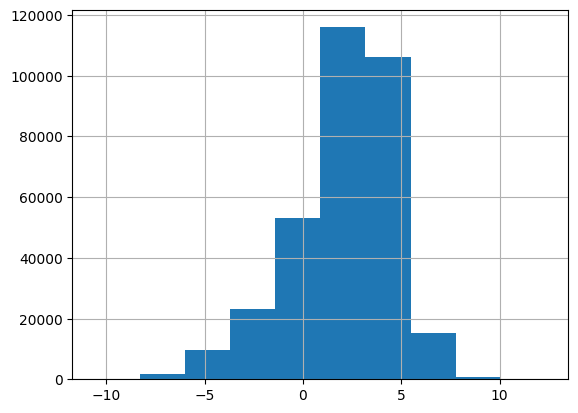

In [19]:
df["LN_IC50"].hist()

<Axes: >

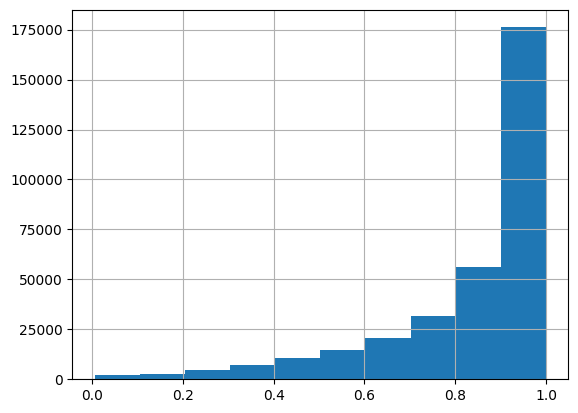

In [20]:
df["AUC"].hist()

# AUC is biased and LN_IC50 is following normal distribution, so chose LN_IC50

## Next Steps

- **Standardize LN_IC50 per drug (z-score)** to remove scale and mean differences.  
- **Use LN_IC50 as the main regression target** with MSE or Huber loss.  
- **Ensure direction consistency**: higher sensitivity = lower LN_IC50.  
- **Evaluate per drug** using RMSE/MAE (z-score) and Spearman correlation (ranking).  

In [21]:
r = (
    pd.read_csv("../Aug8_nsc_cid_smiles.csv", index_col=0)[["NAME", "SMILES"]]
    .dropna()
    .drop_duplicates()
)

In [22]:
drugs = df["DRUG_NAME"].unique()
len(drugs)

378

In [23]:
tmp = r[r["NAME"].isin(drugs)]

In [24]:
k = pd.read_csv(
    "/Users/inouey2/Downloads/2775739846192591652.txt.gz", sep="\t", header=None
).dropna()
k.columns = tmp.columns

In [25]:
hand = [
    ["A-484954", "CCN1C(=O)C2=CC(=C(N=C2N(C1=O)C3CC3)N)C(=O)N"],
    ["JQ12", "O=C(NC1=CC(C2=CC=CS2)=CC=C1N)C3=CC=C(NC(C)=O)C=C3"],
    [
        "HG-6-71-01",
        "COC(=C1CNC(=CC(NC(C(=CC=C(C2C(F)(F)F)CN(CCN3CC)CC3)C=2)=O)=CC2)C=2C)C(=C(N=C1)N1)C=C1",
    ],
    [
        "MPS-1-IN-1",
        "O=S(C(C=CC=C1)=C1NC2=CC(NC3=C(OC)C=C(N4CCC(O)CC4)C=C3)=NC5=C2C=CN5)(C(C)C)=O",
    ],
    [
        "THZ-1-87",
        "CN(C)CC=CC(=O)NC1=CC=C(C=C1)C(=O)NC2=CC=CC(=C2)NC3=NC=C(C(=N3)C4=CNC5=CC=CC=C54)Cl",
    ],
    ["JNK-9L", "Fc1cc(cc(c1)c1ccnc(n1)Nc1ccc(cc1)n1cnc(n1)N1CCOCC1)N1CCOCC1"],
]
hand = pd.DataFrame(hand, columns=tmp.columns)

In [26]:
tmp = pd.concat([tmp, k, hand]).drop_duplicates()
tmp

,NAME,SMILES
11,Methotrexate,CN(CC1=CN=C2C(=N1)C(=NC(=N2)N)N)C3=CC=C(C=C3)C...
67,Pyrimethamine,CCC1=C(C(=NC(=N1)N)N)C2=CC=C(C=C2)Cl
472,5-Fluorouracil,C1=C(C(=O)NC(=O)N1)F
585,Mitomycin-C,CC1=C(C(=O)C2=C(C1=O)N3CC4C(C3(C2COC(=O)N)OC)N4)N
983,Vinblastine,CCC1(CC2CC(C3=C(CCN(C2)C1)C4=CC=CC=C4N3)(C5=C(...
...,...,...
1,JQ12,O=C(NC1=CC(C2=CC=CS2)=CC=C1N)C3=CC=C(NC(C)=O)C=C3
2,HG-6-71-01,COC(=C1CNC(=CC(NC(C(=CC=C(C2C(F)(F)F)CN(CCN3CC...
3,MPS-1-IN-1,O=S(C(C=CC=C1)=C1NC2=CC(NC3=C(OC)C=C(N4CCC(O)C...
4,THZ-1-87,CN(C)CC=CC(=O)NC1=CC=C(C=C1)C(=O)NC2=CC=CC(=C2...


In [27]:
merged = df.merge(tmp, left_on="DRUG_NAME", right_on="NAME", how="inner")
merged = merged[["COSMIC_ID", "NAME", "LN_IC50", "SMILES"]]
merged.head()

,COSMIC_ID,NAME,LN_IC50,SMILES
0,684057,Erlotinib,3.966813,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...
1,684059,Erlotinib,2.692090,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...
2,684062,Erlotinib,2.477990,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...
3,684072,Erlotinib,2.033564,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...
4,687448,Erlotinib,2.966007,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...


In [28]:
merged["Z_score"] = merged.groupby("NAME")["LN_IC50"].transform(
    lambda x: (x - x.mean()) / x.std(ddof=0) if x.std(ddof=0) > 0 else 0
)
merged.head()

,COSMIC_ID,NAME,LN_IC50,SMILES,Z_score
0,684057,Erlotinib,3.966813,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,1.305495
1,684059,Erlotinib,2.692090,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,0.166286
2,684062,Erlotinib,2.477990,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,-0.025053
3,684072,Erlotinib,2.033564,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,-0.422233
4,687448,Erlotinib,2.966007,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,0.411083


In [29]:
merged.to_csv("dataset/gdsc/cellline_info.csv.gz", compression="gzip")